## Setup: Mount Google Drive

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### List Carla Dataset Contents

## Setup: Import Libraries

In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

List Dataset Contents

In [28]:
import os

print(os.listdir("/content/drive/MyDrive/carla_dataset"))

['test.zip', 'train.zip', 'validation.zip', 'train', 'test', 'validation', 'test-fog.zip', 'test-night.zip', 'test-town-01.zip', 'traffic_light_model.pth', 'pedestrian_model.pth', 'vehicle_model.pth']


### Initial Setup and Dataset Overview

### 1. Define Model Architecture and Load Pre-trained Models

First, I'll define a simple Convolutional Neural Network (CNN) architecture. This architecture will be used for all three binary classification tasks (pedestrian, vehicle, traffic light). Then, I'll load the pre-trained weights from your Google Drive into instances of this model.

_Note: If your actual trained models have a different architecture, this step might fail. In that case, we'll need to define the correct architecture._

In [29]:
import torch.nn as nn

class BinaryClassifierCNN(nn.Module):
    def __init__(self):
        super(BinaryClassifierCNN, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)

pedestrian_model = BinaryClassifierCNN()
vehicle_model = BinaryClassifierCNN()
traffic_light_model = BinaryClassifierCNN()

try:
    pedestrian_model.load_state_dict(torch.load('/content/drive/MyDrive/carla_dataset/pedestrian_model.pth'))
    vehicle_model.load_state_dict(torch.load('/content/drive/MyDrive/carla_dataset/vehicle_model.pth'))
    traffic_light_model.load_state_dict(torch.load('/content/drive/MyDrive/carla_dataset/traffic_light_model.pth'))

    print("Models loaded successfully!")

    pedestrian_model.eval()
    vehicle_model.eval()
    traffic_light_model.eval()
    print("Models set to evaluation mode.")

except Exception as e:
    print(f"Error loading models: {e}")
    print("Please ensure the model architectures match the saved state dictionaries and paths are correct. The current model assumes a 224x224 input image size for the linear layer calculation.")

Models loaded successfully!
Models set to evaluation mode.


### 2. Implement Fast Gradient Sign Method (FGSM)

Before implementing FGSM, we need to define the image transformations for our input images, as our models were trained on 224x224 images with specific normalization. We'll also set up the device for computation (GPU if available, otherwise CPU).


In [30]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

pedestrian_model.to(device)
vehicle_model.to(device)
traffic_light_model.to(device);

criterion = nn.BCEWithLogitsLoss()

def fgsm_attack(model, image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    perturbed_image = torch.clamp(perturbed_image, min=-2.5, max=2.5)
    return perturbed_image

def predict(model, image):
    model.eval()
    output = model(image)
    prob = torch.sigmoid(output)
    pred = (prob > 0.5).float()
    return pred, prob

print("FGSM attack function and prediction helper defined.")

Using device: cpu
FGSM attack function and prediction helper defined.


#### Define Visualization Helper Functions

### 3. Generate Adversarial Examples using FGSM

Now, let's pick a sample image from your dataset, apply the FGSM attack for different `ε` (epsilon) values, and visualize the clean and adversarial images side-by-side. We'll also see how the model's prediction changes.

Loading image: /content/drive/MyDrive/carla_dataset/test/rgb-front/018190.jpg

--- Testing with pedestrian model ---
Original image prediction (pedestrian): 0 (Probability: 0.0000)
  Epsilon 0.01: Attack failed. New prediction: 0 (Probability: 0.0000)
  Epsilon 0.05: Attack failed. New prediction: 0 (Probability: 0.0000)
  Epsilon 0.1: Attack failed. New prediction: 0 (Probability: 0.0000)


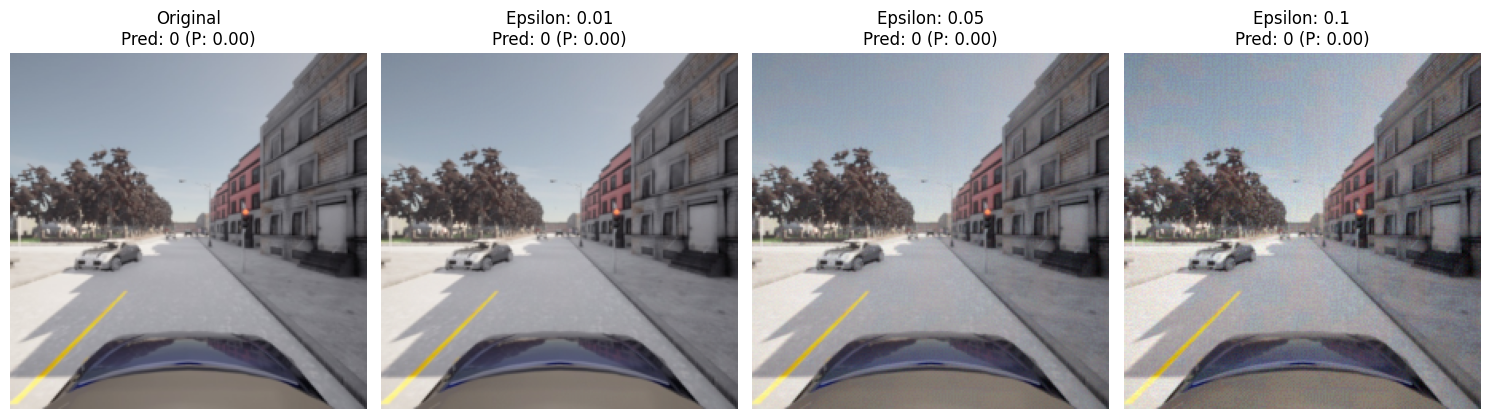


--- Testing with vehicle model ---
Original image prediction (vehicle): 1 (Probability: 1.0000)
  Epsilon 0.01: Attack failed. New prediction: 1 (Probability: 1.0000)
  Epsilon 0.05: Attack failed. New prediction: 1 (Probability: 1.0000)
  Epsilon 0.1: Attack failed. New prediction: 1 (Probability: 1.0000)


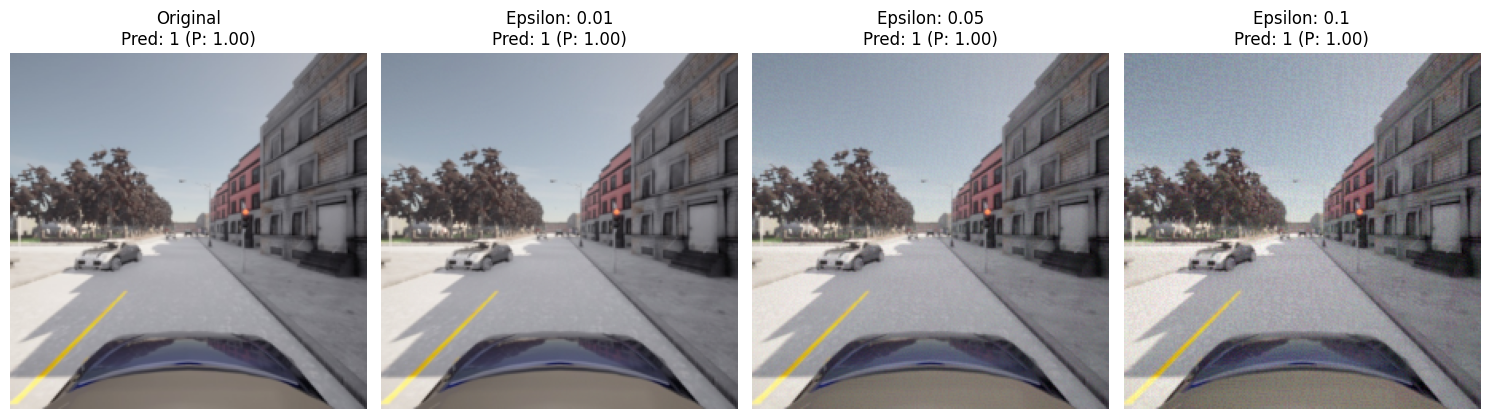


--- Testing with traffic_light model ---
Original image prediction (traffic_light): 1 (Probability: 1.0000)
  Epsilon 0.01: Attack failed. New prediction: 1 (Probability: 1.0000)
  Epsilon 0.05: Attack failed. New prediction: 1 (Probability: 1.0000)
  Epsilon 0.1: Attack failed. New prediction: 1 (Probability: 1.0000)


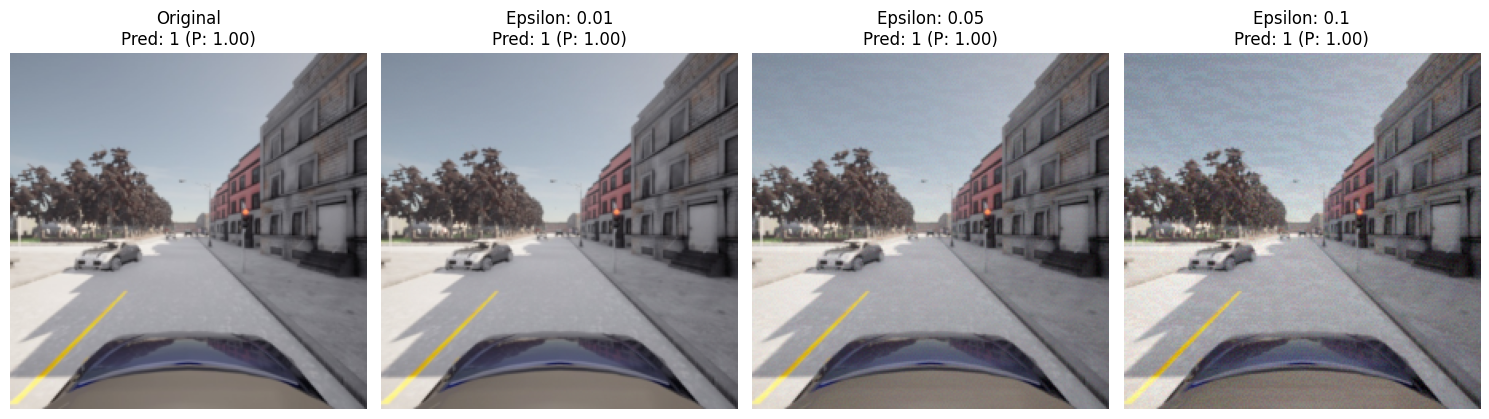

In [31]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

def imshow(img, title=None):
    img = denormalize(img.cpu().squeeze()).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.axis('off')

import random

data_root = '/content/drive/MyDrive/carla_dataset'
test_dir = os.path.join(data_root, 'test')

img_path = None

image_source_dir = os.path.join(test_dir, 'rgb-front')
if os.path.exists(image_source_dir) and os.path.isdir(image_source_dir):
    image_files = [f for f in os.listdir(image_source_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if image_files:
        img_name = random.choice(image_files)
        img_path = os.path.join(image_source_dir, img_name)

if img_path is None:
    print(f"No images found in {image_source_dir}, trying directly in {test_dir}")
    image_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if image_files:
        img_name = random.choice(image_files)
        img_path = os.path.join(test_dir, img_name)

if img_path is None:
    raise FileNotFoundError("Could not find any suitable image file in the expected dataset paths (e.g., 'test/rgb-front' or 'test').")

print(f"Loading image: {img_path}")

original_image = Image.open(img_path).convert('RGB')
original_tensor = preprocess(original_image).unsqueeze(0).to(device)

original_tensor.requires_grad = True

epsilons = [0.01, 0.05, 0.1]

models = {
    "pedestrian": pedestrian_model,
    "vehicle": vehicle_model,
    "traffic_light": traffic_light_model
}

for model_name, model in models.items():
    print(f"\n--- Testing with {model_name} model ---")
    output = model(original_tensor)

    initial_pred_tensor, initial_prob_tensor = predict(model, original_tensor)
    initial_pred = initial_pred_tensor.item()
    initial_prob = initial_prob_tensor.item()

    print(f"Original image prediction ({model_name}): {initial_pred:.0f} (Probability: {initial_prob:.4f})")

    target_label_for_attack = 1.0 - initial_pred
    target_label_for_attack_tensor = torch.tensor([[target_label_for_attack]], device=device);

    original_tensor.grad = None

    loss = criterion(output, target_label_for_attack_tensor)

    loss.backward()

    data_grad = original_tensor.grad.data

    plt.figure(figsize=(15, 5))
    plt.subplot(1, len(epsilons) + 1, 1)
    imshow(original_tensor.cpu().detach(), title=f"Original\nPred: {initial_pred:.0f} (P: {initial_prob:.2f})")

    for i, eps in enumerate(epsilons):
        perturbed_image = fgsm_attack(model, original_tensor, eps, data_grad)
        new_pred_tensor, new_prob_tensor = predict(model, perturbed_image)
        new_pred = new_pred_tensor.item()
        new_prob = new_prob_tensor.item()

        plt.subplot(1, len(epsilons) + 1, i + 2)
        imshow(perturbed_image.cpu().detach(), title=f"Epsilon: {eps}\nPred: {new_pred:.0f} (P: {new_prob:.2f})")

        if initial_pred != new_pred:
            print(f"  Epsilon {eps}: Attack successful! New prediction: {new_pred:.0f} (Probability: {new_prob:.4f})")
        else:
            print(f"  Epsilon {eps}: Attack failed. New prediction: {new_pred:.0f} (Probability: {new_prob:.4f})")
    plt.tight_layout()
    plt.show()

### 4. Evaluate Model Recall and Robustness

Now, let's implement the evaluation logic:
1.  Define a function to calculate recall.
2.  Iterate through each model and epsilon value.
3.  Generate adversarial examples for a subset of the test data.
4.  Evaluate and report the recall drop.

In [32]:
from sklearn.metrics import recall_score

def evaluate_model_recall(model, dataloader, device, epsilon=0, target_label_for_attack=None, fgsm_func=None):
    model.eval()
    true_labels = []
    predictions = []

    for i, (images, labels) in enumerate(dataloader):
        if i * dataloader.batch_size >= 100 and dataloader.dataset.__len__() > 100:
            break

        images = images.to(device)
        labels = labels.to(device)

        if epsilon > 0 and fgsm_func is not None and target_label_for_attack is not None:
            images.requires_grad = True
            output = model(images)
            loss = criterion(output, torch.full_like(output, target_label_for_attack))
            model.zero_grad()
            loss.backward()
            data_grad = images.grad.data
            images = fgsm_func(model, images, epsilon, data_grad)

        with torch.no_grad():
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

        true_labels.extend(labels.cpu().numpy())
        predictions.extend(preds.cpu().numpy())

    if len(true_labels) == 0 or len(predictions) == 0:
        print("No samples processed for recall calculation.")
        return 0.0

    recall = recall_score(true_labels, predictions, average='binary', zero_division=0)
    return recall

print("Evaluation function 'evaluate_model_recall' defined.")

Evaluation function 'evaluate_model_recall' defined.


#### Define Recall Evaluation Function

### 4.1 Define CarlaTestDataset and Create DataLoaders

In [33]:
import json
from torch.utils.data import Dataset, DataLoader

class CarlaTestDataset(Dataset):
    def __init__(self, root_dir, transform=None, target_category=None):
        self.root_dir = root_dir
        self.transform = transform
        self.target_category = target_category

        self.image_files = []
        self.annotations = {}

        annotations_path = os.path.join(root_dir, 'annotations.json')
        if os.path.exists(annotations_path):
            with open(annotations_path, 'r') as f:
                self.annotations = json.load(f)
        else:
            raise FileNotFoundError(f"Annotation file not found at {annotations_path}")

        image_dir = os.path.join(root_dir, 'rgb-front')
        if not os.path.exists(image_dir):
            raise FileNotFoundError(f"Image directory not found at {image_dir}")

        for img_name in os.listdir(image_dir):
            if img_name.endswith('.jpg') or img_name.endswith('.png'):
                annotation_key_with_ext = img_name
                annotation_key_without_ext = os.path.splitext(img_name)[0]

                if annotation_key_with_ext in self.annotations and self.target_category in self.annotations[annotation_key_with_ext]:
                    self.image_files.append(img_name);
                elif annotation_key_without_ext in self.annotations and self.target_category in self.annotations[annotation_key_without_ext]:
                    self.image_files.append(img_name)

        if not self.image_files:
            raise RuntimeError(f"No images found with annotations for category '{self.target_category}' in {image_dir}")

        print(f"Initialized CarlaTestDataset for '{self.target_category}' with {len(self.image_files)} images.")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, 'rgb-front', img_name)
        image = Image.open(img_path).convert('RGB')

        annotation_key = img_name
        if annotation_key not in self.annotations:
             annotation_key = os.path.splitext(img_name)[0]

        label = float(self.annotations[annotation_key][self.target_category])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

#### (Superseded) CarlaTestDataset Definition - JSON (Duplicate)

In [34]:
import json
from torch.utils.data import Dataset, DataLoader

class CarlaTestDataset(Dataset):
    def __init__(self, root_dir, transform=None, target_category=None):
        self.root_dir = root_dir
        self.transform = transform
        self.target_category = target_category

        self.image_files = []
        self.annotations = {}

        annotations_path = os.path.join(root_dir, 'annotations.json')
        if os.path.exists(annotations_path):
            with open(annotations_path, 'r') as f:
                self.annotations = json.load(f)
        else:
            raise FileNotFoundError(f"Annotation file not found at {annotations_path}")

        image_dir = os.path.join(root_dir, 'rgb-front')
        if not os.path.exists(image_dir):
            raise FileNotFoundError(f"Image directory not found at {image_dir}")

        for img_name in os.listdir(image_dir):
            if img_name.endswith('.jpg') or img_name.endswith('.png'):
                annotation_key_with_ext = img_name
                annotation_key_without_ext = os.path.splitext(img_name)[0]

                if annotation_key_with_ext in self.annotations and self.target_category in self.annotations[annotation_key_with_ext]:
                    self.image_files.append(img_name);
                elif annotation_key_without_ext in self.annotations and self.target_category in self.annotations[annotation_key_without_ext]:
                    self.image_files.append(img_name)

        if not self.image_files:
            raise RuntimeError(f"No images found with annotations for category '{self.target_category}' in {image_dir}")

        print(f"Initialized CarlaTestDataset for '{self.target_category}' with {len(self.image_files)} images.")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, 'rgb-front', img_name)
        image = Image.open(img_path).convert('RGB')

        annotation_key = img_name
        if annotation_key not in self.annotations:
             annotation_key = os.path.splitext(img_name)[0]

        label = float(self.annotations[annotation_key][self.target_category])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

#### CarlaTestDataset Definition - CSV (Active)

In [35]:
import json
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd

class CarlaTestDataset(Dataset):
    def __init__(self, root_dir, transform=None, target_category=None):
        self.root_dir = root_dir
        self.transform = transform
        self.target_category = target_category

        self.image_files = []
        self.annotations = {}

        labels_csv_path = os.path.join(root_dir, 'labels.csv')
        if os.path.exists(labels_csv_path):
            df_labels = pd.read_csv(labels_csv_path)
            for _, row in df_labels.iterrows():
                img_filename = f'{int(row["frame"]):06d}.jpg'
                self.annotations[img_filename] = {
                    'pedestrian': float(row['has_pedestrian']),
                    'vehicle': float(row['has_vehicle']),
                    'traffic_light': float(row['has_traffic_light'])
                }
        else:
            raise FileNotFoundError(f"Annotation file labels.csv not found at {labels_csv_path}")

        image_dir = os.path.join(root_dir, 'rgb-front')
        if not os.path.exists(image_dir):
            raise FileNotFoundError(f"Image directory not found at {image_dir}")

        all_image_names_in_dir = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for img_name in all_image_names_in_dir:
            if img_name in self.annotations and self.target_category in self.annotations[img_name]:
                self.image_files.append(img_name)

        if not self.image_files:
            raise RuntimeError(f"No images found with annotations for category '{self.target_category}' in {image_dir}")

        print(f"Initialized CarlaTestDataset for '{self.target_category}' with {len(self.image_files)} images.")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, 'rgb-front', img_name)
        image = Image.open(img_path).convert('RGB')

        label = self.annotations[img_name][self.target_category]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

test_root_dir = '/content/drive/MyDrive/carla_dataset/test'
batch_size = 32

pedestrian_dataset = CarlaTestDataset(root_dir=test_root_dir, transform=preprocess, target_category='pedestrian')
pedestrian_dataloader = DataLoader(pedestrian_dataset, batch_size=batch_size, shuffle=False)

vehicle_dataset = CarlaTestDataset(root_dir=test_root_dir, transform=preprocess, target_category='vehicle')
vehicle_dataloader = DataLoader(vehicle_dataset, batch_size=batch_size, shuffle=False)

traffic_light_dataset = CarlaTestDataset(root_dir=test_root_dir, transform=preprocess, target_category='traffic_light')
traffic_light_dataloader = DataLoader(traffic_light_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders for pedestrian, vehicle, and traffic light test sets created.")

Initialized CarlaTestDataset for 'pedestrian' with 3600 images.
Initialized CarlaTestDataset for 'vehicle' with 3600 images.
Initialized CarlaTestDataset for 'traffic_light' with 3600 images.
DataLoaders for pedestrian, vehicle, and traffic light test sets created.


### Verify `labels.csv` Content

In [36]:
import os
print(os.listdir('/content/drive/MyDrive/carla_dataset/test'))

['rgb-front', 'sim.log', 'imu.feather', 'segmentation-front', '.hydra', 'actions.feather', 'labels.feather', 'gnss.feather', 'collisions.feather', 'carla.log', 'labels.csv', 'weather.feather']


#### Display `labels.csv` Head

In [37]:
import pandas as pd
import os

labels_csv_path = os.path.join('/content/drive/MyDrive/carla_dataset/test', 'labels.csv')

if os.path.exists(labels_csv_path):
    df_labels = pd.read_csv(labels_csv_path)
    print("Labels.csv content:")
    print(df_labels.head())
    print(f"\nColumns: {df_labels.columns.tolist()}")
else:
    print(f"Error: labels.csv not found at {labels_csv_path}")

Labels.csv content:
   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False           False        False                15   
1     10               True           False         True               299   
2     20               True           False         True               298   
3     30               True           False         True               297   
4     40               True           False         True               297   

   px_pedestrian  px_vehicle  
0              0          35  
1              0         116  
2              0         307  
3              0         258  
4              0         249  

Columns: ['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']


### Execute Robustness Evaluation

In [38]:
epsilons = [0.01, 0.05, 0.1]

model_eval_results = {}

models_to_evaluate = {
    "pedestrian": {"model": pedestrian_model, "dataloader": pedestrian_dataloader},
    "vehicle": {"model": vehicle_model, "dataloader": vehicle_dataloader},
    "traffic_light": {"model": traffic_light_model, "dataloader": traffic_light_dataloader}
}

for model_name, data in models_to_evaluate.items():
    model = data["model"]
    dataloader = data["dataloader"]
    print(f"\n--- Evaluating {model_name} model ---")

    clean_recall = evaluate_model_recall(model, dataloader, device)
    print(f"  Clean input recall: {clean_recall:.4f}")

    model_eval_results[model_name] = {"clean_recall": clean_recall, "adversarial_recalls": {}}

    for eps in epsilons:
        adversarial_recall = evaluate_model_recall(model, dataloader, device, epsilon=eps, target_label_for_attack=0.0, fgsm_func=fgsm_attack)
        recall_drop = clean_recall - adversarial_recall
        print(f"  Adversarial recall (ε={eps}): {adversarial_recall:.4f} (Recall Drop: {recall_drop:.4f})")
        model_eval_results[model_name]["adversarial_recalls"][eps] = adversarial_recall

print("\n--- Robustness Evaluation Summary ---")
for model_name, results in model_eval_results.items():
    print(f"\nModel: {model_name}")
    print(f"  Clean Recall: {results['clean_recall']:.4f}")
    for eps, adv_recall in results["adversarial_recalls"].items():
        recall_drop = results['clean_recall'] - adv_recall
        print(f"  Adversarial Recall (ε={eps}): {adv_recall:.4f} (Recall Drop: {recall_drop:.4f})")


--- Evaluating pedestrian model ---
  Clean input recall: 0.2571
  Adversarial recall (ε=0.01): 0.3714 (Recall Drop: -0.1143)
  Adversarial recall (ε=0.05): 0.5714 (Recall Drop: -0.3143)
  Adversarial recall (ε=0.1): 0.8857 (Recall Drop: -0.6286)

--- Evaluating vehicle model ---
  Clean input recall: 0.9149
  Adversarial recall (ε=0.01): 1.0000 (Recall Drop: -0.0851)
  Adversarial recall (ε=0.05): 1.0000 (Recall Drop: -0.0851)
  Adversarial recall (ε=0.1): 1.0000 (Recall Drop: -0.0851)

--- Evaluating traffic_light model ---
  Clean input recall: 0.9783
  Adversarial recall (ε=0.01): 0.9783 (Recall Drop: 0.0000)
  Adversarial recall (ε=0.05): 1.0000 (Recall Drop: -0.0217)
  Adversarial recall (ε=0.1): 1.0000 (Recall Drop: -0.0217)

--- Robustness Evaluation Summary ---

Model: pedestrian
  Clean Recall: 0.2571
  Adversarial Recall (ε=0.01): 0.3714 (Recall Drop: -0.1143)
  Adversarial Recall (ε=0.05): 0.5714 (Recall Drop: -0.3143)
  Adversarial Recall (ε=0.1): 0.8857 (Recall Drop: -0.

### Re-run Robustness Evaluation

In [39]:
epsilons = [0.01, 0.05, 0.1]

model_eval_results = {}

models_to_evaluate = {
    "pedestrian": {"model": pedestrian_model, "dataloader": pedestrian_dataloader},
    "vehicle": {"model": vehicle_model, "dataloader": vehicle_dataloader},
    "traffic_light": {"model": traffic_light_model, "dataloader": traffic_light_dataloader}
}

for model_name, data in models_to_evaluate.items():
    model = data["model"]
    dataloader = data["dataloader"]
    print(f"\n--- Evaluating {model_name} model ---")

    clean_recall = evaluate_model_recall(model, dataloader, device)
    print(f"  Clean input recall: {clean_recall:.4f}")

    model_eval_results[model_name] = {"clean_recall": clean_recall, "adversarial_recalls": {}}

    for eps in epsilons:
        adversarial_recall = evaluate_model_recall(model, dataloader, device, epsilon=eps, target_label_for_attack=0.0, fgsm_func=fgsm_attack)
        recall_drop = clean_recall - adversarial_recall
        print(f"  Adversarial recall (ε={eps}): {adversarial_recall:.4f} (Recall Drop: {recall_drop:.4f})")
        model_eval_results[model_name]["adversarial_recalls"][eps] = adversarial_recall

print("\n--- Robustness Evaluation Summary ---")
for model_name, results in model_eval_results.items():
    print(f"\nModel: {model_name}")
    print(f"  Clean Recall: {results['clean_recall']:.4f}")
    for eps, adv_recall in results["adversarial_recalls"].items():
        recall_drop = results['clean_recall'] - adv_recall
        print(f"  Adversarial Recall (ε={eps}): {adv_recall:.4f} (Recall Drop: {recall_drop:.4f})")


--- Evaluating pedestrian model ---
  Clean input recall: 0.2571
  Adversarial recall (ε=0.01): 0.3714 (Recall Drop: -0.1143)
  Adversarial recall (ε=0.05): 0.5714 (Recall Drop: -0.3143)
  Adversarial recall (ε=0.1): 0.8857 (Recall Drop: -0.6286)

--- Evaluating vehicle model ---
  Clean input recall: 0.9149
  Adversarial recall (ε=0.01): 1.0000 (Recall Drop: -0.0851)
  Adversarial recall (ε=0.05): 1.0000 (Recall Drop: -0.0851)
  Adversarial recall (ε=0.1): 1.0000 (Recall Drop: -0.0851)

--- Evaluating traffic_light model ---
  Clean input recall: 0.9783
  Adversarial recall (ε=0.01): 0.9783 (Recall Drop: 0.0000)
  Adversarial recall (ε=0.05): 1.0000 (Recall Drop: -0.0217)
  Adversarial recall (ε=0.1): 1.0000 (Recall Drop: -0.0217)

--- Robustness Evaluation Summary ---

Model: pedestrian
  Clean Recall: 0.2571
  Adversarial Recall (ε=0.01): 0.3714 (Recall Drop: -0.1143)
  Adversarial Recall (ε=0.05): 0.5714 (Recall Drop: -0.3143)
  Adversarial Recall (ε=0.1): 0.8857 (Recall Drop: -0.